# 24. Conjugate Gradient

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. Show that solving $A\mathbf{x} = \mathbf{b}$ for symmetric positive definite $A$ is the same
   as **minimising a quadratic**.
2. Derive **steepest descent** and measure the zigzag that limits it.
3. Define the **$A$-inner product** and **conjugacy**, and say why they are the right notions.
4. Derive **conjugate gradient**, and explain why it needs only three vectors.
5. Use the $O(\sqrt{\kappa})$ bound, and measure how loose it is.
6. Explain why **eigenvalue clustering** beats the condition number, with measurement.
7. Recognise CG and Lanczos as the same recurrence.
8. Explain why **finite precision destroys finite termination**, and measure it.

## Prerequisites

Lesson 20 (symmetric positive definite matrices, the $A$-norm). Lesson 19 (conditioning).
Lesson 23 (why stationary methods stall). Lesson 16 (projection and orthogonality).

---

## 1. Solving is minimising

> **Theorem 24.1.** For symmetric positive definite $A$, define
> $$\phi(\mathbf{x}) = \tfrac12\mathbf{x}^TA\mathbf{x} - \mathbf{b}^T\mathbf{x}.$$
> Then $\phi$ has a unique minimiser, and it is the solution of $A\mathbf{x} = \mathbf{b}$.
>
> *Proof.* $\nabla\phi = A\mathbf{x} - \mathbf{b}$, which vanishes exactly at the solution. The
> Hessian is $A$, positive definite, so the stationary point is a strict minimum and there is
> only one. $\square$

**Both hypotheses are used.** Symmetry makes $\nabla\phi = A\mathbf{x} - \mathbf{b}$ rather than
$\tfrac12(A + A^T)\mathbf{x} - \mathbf{b}$; positive definiteness makes the stationary point a
minimum rather than a saddle.

The residual $\mathbf{r} = \mathbf{b} - A\mathbf{x}$ is therefore $-\nabla\phi$: **the residual
is the steepest descent direction**. That is the bridge between linear algebra and optimization,
and Part 12 crosses it in the other direction.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import krylov as kr, banded as bd, linalg as la, cholesky as ch, iterative as it

A_demo = np.array([[3.0, 1.0], [1.0, 2.0]])
b_demo = np.array([5.0, 5.0])
x_star = np.linalg.solve(A_demo, b_demo)


def phi(x, A=A_demo, b=b_demo):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    return 0.5 * x @ A @ x - b @ x


print(f"A =\n{A_demo}\nb = {b_demo}\n")
print(f"solution of A x = b : {x_star}")
print(f"phi at the solution : {phi(x_star):.10f}")
print()
print("phi at nearby points, to confirm it is a minimum:")
rng24 = np.random.default_rng(24)
worst = -np.inf
for _ in range(2000):
    d = rng24.standard_normal(A_demo.shape[0])
    worst = max(worst, phi(x_star) - phi(x_star + 0.01 * d / np.linalg.norm(d)))
print(f"   largest amount by which any nearby point BEAT the solution: {worst:.3e}")
print(f"   gradient at the solution: {A_demo @ x_star - b_demo}")
assert worst < 0

A =
[[3. 1.]
 [1. 2.]]
b = [5. 5.]

solution of A x = b : [1. 2.]
phi at the solution : -7.5000000000

phi at nearby points, to confirm it is a minimum:
   largest amount by which any nearby point BEAT the solution: -6.910e-05
   gradient at the solution: [0. 0.]


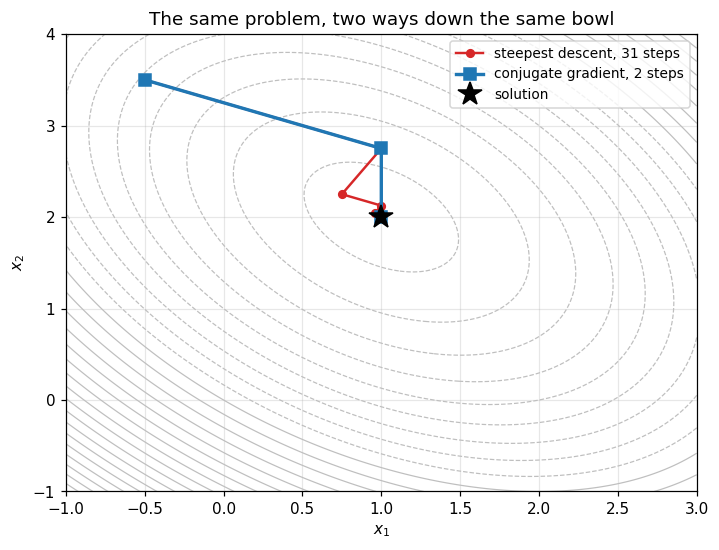

steepest descent : 31 steps
conjugate gradient: 2 steps, which is n = 2

CG reaches the exact solution in n steps on an n by n problem. that is
not a coincidence and section 4 explains it.


In [3]:
xs = np.linspace(-1, 3, 200)
ys = np.linspace(-1, 4, 200)
X, Y = np.meshgrid(xs, ys)
Z = np.array([[phi(np.array([xv, yv])) for xv in xs] for yv in ys])

sd = kr.steepest_descent(A_demo, b_demo, x0=np.array([-0.5, 3.5]), tol=1e-12, max_iter=40)
cg = kr.conjugate_gradient(A_demo, b_demo, x0=np.array([-0.5, 3.5]), tol=1e-12)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.contour(X, Y, Z, levels=30, colors="0.75", linewidths=0.8)
ax.plot(sd.iterates[:, 0], sd.iterates[:, 1], "C3o-", lw=1.6, ms=5,
        label=f"steepest descent, {sd.n_iter} steps")
ax.plot(cg.iterates[:, 0], cg.iterates[:, 1], "C0s-", lw=2.2, ms=8,
        label=f"conjugate gradient, {cg.n_iter} steps")
ax.plot(x_star[0], x_star[1], "k*", ms=16, label="solution")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("The same problem, two ways down the same bowl")
ax.legend(fontsize=9)
plt.show()

print(f"steepest descent : {sd.n_iter} steps")
print(f"conjugate gradient: {cg.n_iter} steps, which is n = {A_demo.shape[0]}")
print()
print("CG reaches the exact solution in n steps on an n by n problem. that is")
print("not a coincidence and section 4 explains it.")
assert cg.n_iter <= A_demo.shape[0]

## 2. Steepest descent, and why it zigzags

Move along the residual, by the amount that minimises $\phi$ along that line:

$$\alpha = \arg\min_t \phi(\mathbf{x} + t\mathbf{r}) = \frac{\mathbf{r}^T\mathbf{r}}{\mathbf{r}^TA\mathbf{r}}.$$

That is an exact one-dimensional minimisation, so this is already better than lesson 23's fixed
steps. It is still poor, and the reason is visible in the picture.

> **Proposition 24.2.** Consecutive steepest descent directions are **exactly orthogonal**.
>
> *Proof.* The step is optimal along $\mathbf{r}_k$, so
> $\frac{d}{dt}\phi(\mathbf{x}_k + t\mathbf{r}_k) = 0$ at $t = \alpha$, which says
> $-\mathbf{r}_{k+1}^T\mathbf{r}_k = 0$. $\square$

Orthogonal sounds good and is not. It means every step is **perpendicular to the last**, so in a
long narrow valley the path bounces from wall to wall, and each step undoes part of the previous
one's progress.

In [4]:
narrow = np.array([[10.0, 0.0], [0.0, 1.0]])          # a valley 10 times longer than wide
b_n = narrow @ np.array([1.0, 1.0])
run = kr.steepest_descent(narrow, b_n, tol=1e-12, max_iter=80)
steps = np.diff(run.iterates, axis=0)

print(f"kappa of this matrix: {la.condition_number(narrow, 2):.1f}\n")
print("angle between consecutive steps:")
for i in range(min(6, len(steps) - 1)):
    c = steps[i] @ steps[i+1] / (np.linalg.norm(steps[i]) * np.linalg.norm(steps[i+1]))
    print(f"   step {i} to {i+1}: {np.degrees(np.arccos(np.clip(c, -1, 1))):.4f} degrees")

print()
print("exactly 90 degrees, every time, which is Proposition 24.2.")
print(f"steepest descent took {run.n_iter} steps on a 2 by 2 problem.")
print("CG takes 2.")
assert abs(np.degrees(np.arccos(np.clip(
    steps[0] @ steps[1] / (np.linalg.norm(steps[0]) * np.linalg.norm(steps[1])), -1, 1))) - 90) < 1e-6

kappa of this matrix: 10.0

angle between consecutive steps:
   step 0 to 1: 90.0000 degrees
   step 1 to 2: 90.0000 degrees
   step 2 to 3: 90.0000 degrees
   step 3 to 4: 90.0000 degrees
   step 4 to 5: 90.0000 degrees
   step 5 to 6: 90.0000 degrees

exactly 90 degrees, every time, which is Proposition 24.2.
steepest descent took 21 steps on a 2 by 2 problem.
CG takes 2.


The rate is known exactly:

$$\|\mathbf{e}_{k+1}\|_A \le \frac{\kappa - 1}{\kappa + 1}\|\mathbf{e}_k\|_A
= \left(1 - \frac{2}{\kappa+1}\right)\|\mathbf{e}_k\|_A,$$

so the iteration count is $O(\kappa)$. Better than lesson 23 but still linear in $\kappa$.

## 3. Conjugacy: the right notion of orthogonal

The zigzag happens because "orthogonal" was measured in the wrong inner product. The bowl is
stretched by $A$, so measure angles in the geometry $A$ defines.

> **Definition 24.3.** For symmetric positive definite $A$, the **$A$-inner product** is
> $$\langle\mathbf{x},\mathbf{y}\rangle_A = \mathbf{x}^TA\mathbf{y},
> \qquad \|\mathbf{x}\|_A = \sqrt{\mathbf{x}^TA\mathbf{x}}.$$
> Vectors with $\mathbf{p}_i^TA\mathbf{p}_j = 0$ are called **$A$-conjugate**.

This is a genuine inner product **exactly because $A$ is positive definite** (lesson 20): that
is what makes $\|\mathbf{x}\|_A = 0$ imply $\mathbf{x} = 0$. Drop positive definiteness and the
whole construction collapses.

> **Theorem 24.4 (why conjugacy is the right idea).** If $\mathbf{p}_0,\dots,\mathbf{p}_{n-1}$
> are $A$-conjugate and nonzero, then minimising $\phi$ over their whole span decomposes into
> $n$ **independent** one-dimensional minimisations.
>
> *Proof.* Write $\mathbf{x} = \sum_j t_j\mathbf{p}_j$. Then
> $$\phi(\mathbf{x}) = \tfrac12\sum_{i,j}t_it_j\mathbf{p}_i^TA\mathbf{p}_j
> - \sum_j t_j\mathbf{b}^T\mathbf{p}_j
> = \sum_j\Big(\tfrac12 t_j^2\,\mathbf{p}_j^TA\mathbf{p}_j - t_j\mathbf{b}^T\mathbf{p}_j\Big),$$
> because every cross term vanishes by conjugacy. Each summand involves one $t_j$ only, so they
> minimise separately. $\square$

**This is the whole idea.** With conjugate directions, a step along $\mathbf{p}_k$ **cannot undo**
progress made along $\mathbf{p}_0,\dots,\mathbf{p}_{k-1}$, because they do not interact in
$\phi$. Steepest descent's steps interact, which is exactly the zigzag.

An immediate corollary: after $n$ conjugate steps you have minimised over all of
$\mathbb{R}^n$, so **CG reaches the exact solution in at most $n$ steps** in exact arithmetic.

## 4. Conjugate gradient

The algorithm builds conjugate directions from the residuals as it goes:

```text
CONJUGATE_GRADIENT(A, b, x0)
    r <- b - A x0;   p <- r;   x <- x0
    repeat:
        alpha <- (r.r) / (p . A p)        # optimal step along p
        x     <- x + alpha p
        r_new <- r - alpha A p            # update the residual, no new matvec
        beta  <- (r_new . r_new) / (r . r)
        p     <- r_new + beta p           # the new direction, A-conjugate to all previous
        r     <- r_new
```

Two things are remarkable about this.

**One matrix-vector product per step.** $A\mathbf{p}$ is computed once and reused for both the
step and the residual update.

**Three vectors of storage, no matter how many steps.** The new direction is built from the
current residual and the **previous direction only**, yet it comes out conjugate to *every*
previous direction. That is not obvious and it is the theorem that makes CG practical.

> **Theorem 24.5.** The CG iterates satisfy, at every step $k$:
> $$\mathbf{r}_i^T\mathbf{r}_j = 0 \ (i \ne j), \qquad
> \mathbf{p}_i^TA\mathbf{p}_j = 0 \ (i \ne j),$$
> and $\mathbf{x}_k$ minimises $\|\mathbf{x} - \mathbf{x}^\ast\|_A$ over
> $\mathbf{x}_0 + K_k(A, \mathbf{r}_0)$.

In [5]:
def cg_by_hand(A, b, max_steps=None):
    """Run CG keeping every residual and direction, so the theorem can be inspected."""
    A = np.atleast_2d(np.asarray(A, dtype=float))
    b = np.asarray(b, dtype=float).ravel()
    size = b.size
    max_steps = size if max_steps is None else max_steps
    x = np.zeros(size)
    r = b - A @ x
    p = r.copy()
    residuals, directions = [r.copy()], [p.copy()]
    for _ in range(max_steps):
        Ap = A @ p
        alpha = (r @ r) / (p @ Ap)
        x = x + alpha * p
        r_new = r - alpha * Ap
        if np.linalg.norm(r_new) < 1e-14 * np.linalg.norm(b):
            break
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new
        residuals.append(r.copy())
        directions.append(p.copy())
    return np.array(residuals).T, np.array(directions).T


def worst_off_diagonal(V, weight=None):
    """Largest off-diagonal entry of V^T V, or V^T W V, relative to the diagonal."""
    G = V.T @ (V if weight is None else weight @ V)
    diag = np.abs(np.diag(G)).max()
    G = G - np.diag(np.diag(G))
    return float(np.abs(G).max() / max(diag, 1e-300))


print("checking Theorem 24.5, and finding where it stops holding")
print()
print(f"{'n':>5} {'kappa':>9} {'residuals orthogonal':>22} {'directions A-conjugate':>24}")
print("-" * 64)
for size in [8, 12, 30]:
    for kappa in [1e1, 1e3, 1e6]:
        M = ch.random_spd(size, kappa=kappa, rng=np.random.default_rng(240))
        xt = np.random.default_rng(241).standard_normal(size)
        R, P = cg_by_hand(M, M @ xt)
        print(f"{size:>5} {kappa:>9.0e} {worst_off_diagonal(R):>22.2e} "
              f"{worst_off_diagonal(P, M):>24.2e}")

print()
print("read this table in two directions.")
print()
print("ACROSS a row: at kappa = 10 both quantities are at roundoff, which is")
print("Theorem 24.5 holding exactly. and nothing in the algorithm orthogonalized")
print("against more than the PREVIOUS vector. that is the remarkable part.")
print()
print("DOWN a column: the orthogonality degrades steadily as kappa grows, and by")
print("kappa = 1e6 it is gone. the theorem is about exact arithmetic, and")
print("floating point stops resembling exact arithmetic once kappa is large.")
print()
print("section 8 returns to this, because it is what destroys CG's finite")
print("termination property.")

GOOD_DIM = 12
M_good = ch.random_spd(GOOD_DIM, kappa=1e1, rng=np.random.default_rng(240))
xt_good = np.random.default_rng(241).standard_normal(M_good.shape[0])
R_g, P_g = cg_by_hand(M_good, M_good @ xt_good)
assert worst_off_diagonal(R_g) < 1e-10
assert worst_off_diagonal(P_g, M_good) < 1e-10

checking Theorem 24.5, and finding where it stops holding

    n     kappa   residuals orthogonal   directions A-conjugate
----------------------------------------------------------------
    8     1e+01               5.06e-16                 1.00e-15
    8     1e+03               1.25e-05                 1.50e-05
    8     1e+06               1.73e-03                 1.76e-03
   12     1e+01               1.80e-16                 2.67e-16
   12     1e+03               1.54e-04                 2.75e-04
   12     1e+06               4.77e-03                 1.11e-02
   30     1e+01               7.47e-13                 9.17e-13
   30     1e+03               2.31e-03                 2.12e-03
   30     1e+06               3.13e-03                 3.78e-03

read this table in two directions.

ACROSS a row: at kappa = 10 both quantities are at roundoff, which is
Theorem 24.5 holding exactly. and nothing in the algorithm orthogonalized
against more than the PREVIOUS vector. that is the rema

### Finite termination

In [6]:
print("CG on the model problem: at most n steps\n")
print(f"{'n':>6} {'CG steps':>10} {'<= n?':>8} {'final error':>14}")
print("-" * 42)
rng4 = np.random.default_rng(244)
for size in [1, 2, 5, 20, 60, 150]:
    M = bd.second_difference(size)
    xt = rng4.standard_normal(size)
    res = kr.conjugate_gradient(M, M @ xt, tol=1e-13, keep_history=False)
    print(f"{size:>6} {res.n_iter:>10} {str(res.n_iter <= size):>8} "
          f"{np.linalg.norm(res.x - xt)/np.linalg.norm(xt):>14.2e}")
    assert res.n_iter <= size

CG on the model problem: at most n steps

     n   CG steps    <= n?    final error
------------------------------------------
     1          1     True       0.00e+00
     2          2     True       4.74e-16
     5          5     True       3.24e-16
    20         20     True       3.25e-15
    60         60     True       7.02e-15
   150        150     True       2.26e-14


## 5. The convergence bound

Finite termination is a curiosity: for $n = 10^6$, "at most $n$ steps" is no promise at all.
What matters is that CG is usually far better than that.

> **Theorem 24.6.**
> $$\|\mathbf{e}_k\|_A \le 2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k\|\mathbf{e}_0\|_A.$$

Compare steepest descent's $\left(\frac{\kappa-1}{\kappa+1}\right)^k$. **The $\kappa$ became a
$\sqrt{\kappa}$**, so the iteration count falls from $O(\kappa)$ to $O(\sqrt{\kappa})$.

In [7]:
print("the two bounds, side by side\n")
print(f"{'kappa':>10} {'steepest descent':>20} {'conjugate gradient':>22} {'speedup':>10}")
print("-" * 66)
for kappa in [1e1, 1e2, 1e4, 1e6, 1e8]:
    k_sd = np.log(1e-8) / np.log((kappa - 1) / (kappa + 1))
    k_cg = np.log(1e-8 / 2) / np.log((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1))
    print(f"{kappa:>10.0e} {k_sd:>20,.0f} {k_cg:>22,.0f} {k_sd/k_cg:>10.1f}x")

print()
print("at kappa = 1e8 the difference is ten thousand iterations against one")
print("hundred. that is why CG replaced steepest descent completely.")

the two bounds, side by side

     kappa     steepest descent     conjugate gradient    speedup
------------------------------------------------------------------
     1e+01                   92                     29        3.1x
     1e+02                  921                     95        9.7x
     1e+04               92,103                    956       96.4x
     1e+06            9,210,340                  9,557      963.7x
     1e+08          921,034,039                 95,569     9637.4x

at kappa = 1e8 the difference is ten thousand iterations against one
hundred. that is why CG replaced steepest descent completely.


In [8]:
print("measured, on the model problem\n")
print(f"{'n':>5} {'kappa':>10} {'sqrt(kappa)':>13} {'CG steps':>10} {'SD steps':>10} "
      f"{'ratio':>8}")
print("-" * 62)
rng5 = np.random.default_rng(245)
for size in [10, 20, 40, 80]:
    M = bd.second_difference(size)
    xt = rng5.standard_normal(size)
    rhs = M @ xt
    kap = la.condition_number(M, 2)
    kc = kr.conjugate_gradient(M, rhs, tol=1e-8, max_iter=100000,
                               keep_history=False).n_iter
    ks = kr.steepest_descent(M, rhs, tol=1e-8, max_iter=200000,
                             keep_history=False).n_iter
    print(f"{size:>5} {kap:>10.1f} {np.sqrt(kap):>13.1f} {kc:>10} {ks:>10} "
          f"{ks/kc:>8.1f}x")

print()
print("the ratio grows with n, because SD scales with kappa and CG with its")
print("square root. the CG counts track sqrt(kappa) closely.")

measured, on the model problem

    n      kappa   sqrt(kappa)   CG steps   SD steps    ratio
--------------------------------------------------------------
   10       48.4           7.0         10        315     31.5x
   20      178.1          13.3         20       1003     50.1x
   40      680.6          26.1         40       3471     86.8x
   80     2658.4          51.6         80      10373    129.7x

the ratio grows with n, because SD scales with kappa and CG with its
square root. the CG counts track sqrt(kappa) closely.


### The bound is an upper bound, and a loose one

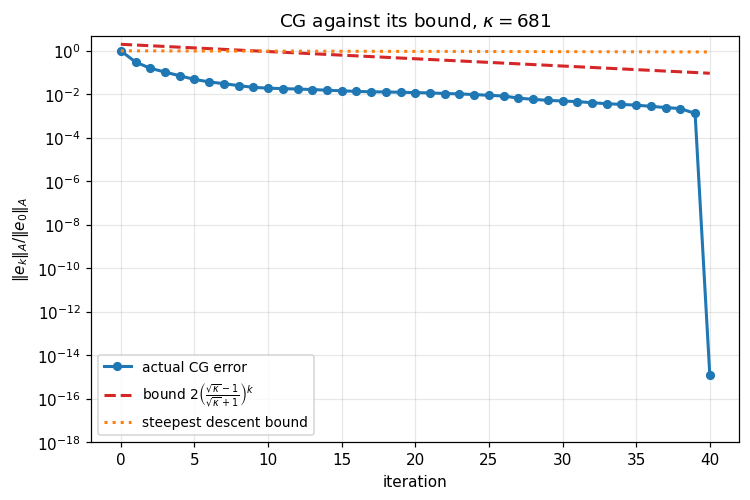

bound violations: 0
at the last step the actual error is 1.3e-14 times the bound.

the bound is never violated and it is enormously pessimistic near the
end, because it depends ONLY on kappa and therefore cannot see the
shape of the spectrum. section 6 shows the shape is what matters.


In [9]:
size = 40
M = bd.second_difference(size)
xt = np.random.default_rng(246).standard_normal(size)
res = kr.conjugate_gradient(M, M @ xt, tol=1e-14, max_iter=2 * size)
err = res.a_norm_errors(M, xt)
err = err / err[0]
steps = np.arange(len(err))
kap = la.condition_number(M, 2)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.semilogy(steps, np.maximum(err, 1e-18), "C0o-", lw=2, ms=5, label="actual CG error")
ax.semilogy(steps, kr.cg_convergence_bound(kap, steps), "C3--", lw=2,
            label=r"bound $2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k$")
ax.semilogy(steps, kr.steepest_descent_bound(kap, steps), "C1:", lw=2,
            label="steepest descent bound")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\|e_k\|_A / \|e_0\|_A$")
ax.set_ylim(1e-18, 5)
ax.set_title(f"CG against its bound, $\\kappa = {kap:.0f}$")
ax.legend(fontsize=9)
plt.show()

violations = int(np.sum(err > kr.cg_convergence_bound(kap, steps) * (1 + 1e-8)))
print(f"bound violations: {violations}")
print(f"at the last step the actual error is "
      f"{err[-1]/kr.cg_convergence_bound(kap, steps[-1]):.1e} times the bound.")
print()
print("the bound is never violated and it is enormously pessimistic near the")
print("end, because it depends ONLY on kappa and therefore cannot see the")
print("shape of the spectrum. section 6 shows the shape is what matters.")
assert violations == 0

## 6. Clustering beats the condition number

The bound uses only $\kappa = \lambda_{\max}/\lambda_{\min}$, which is two numbers. CG actually
depends on **all** the eigenvalues, and it is fast when they are **clustered**.

The reason is that CG's error after $k$ steps is $q(A)\mathbf{e}_0$ for some polynomial $q$ of
degree $k$ with $q(0) = 1$, and CG picks the best such polynomial. If the eigenvalues sit in a
few tight clusters, a low degree polynomial can be small at all of them at once.

> **Corollary 24.7.** If $A$ has only $m$ distinct eigenvalues, CG converges in **at most $m$
> steps**, whatever $\kappa$ is.

In [10]:
from nalib import orthogonality as og

print("two matrices with the SAME condition number\n")
size = 200
rng6 = np.random.default_rng(247)

spread = np.logspace(0, 4, size)
third = size // 3
clustered = np.concatenate([
    1.0 + 1e-3 * rng6.random(third),
    100.0 + 1e-1 * rng6.random(third),
    1e4 + 10.0 * rng6.random(size - 2 * third),
])

print(f"{'spectrum':>22} {'kappa':>12} {'sqrt(kappa)':>13} {'CG iterations':>15}")
print("-" * 66)
for label, s in [("spread evenly", spread), ("three tight clusters", clustered)]:
    Q = og.random_orthogonal(size, rng6)
    M = Q @ np.diag(s) @ Q.T
    M = (M + M.T) / 2
    xt = rng6.standard_normal(size)
    res = kr.conjugate_gradient(M, M @ xt, tol=1e-10, max_iter=size, keep_history=False)
    print(f"{label:>22} {la.condition_number(M, 2):>12.3e} "
          f"{np.sqrt(la.condition_number(M, 2)):>13.1f} {res.n_iter:>15}")

print()
print("identical condition numbers. 200 iterations against 14.")
print()
print("the bound predicts the same behaviour for both, and is wrong about one")
print("of them by a factor of fourteen. kappa is a summary that discards")
print("exactly the information CG uses.")
print()
print("THIS IS THE WHOLE POINT OF LESSON 25. a preconditioner does not have to")
print("reduce kappa. it has to CLUSTER the spectrum, and clustering is both")
print("easier to achieve and worth more.")

two matrices with the SAME condition number

              spectrum        kappa   sqrt(kappa)   CG iterations
------------------------------------------------------------------
         spread evenly    1.000e+04         100.0             200
  three tight clusters    1.001e+04         100.0              14

identical condition numbers. 200 iterations against 14.

the bound predicts the same behaviour for both, and is wrong about one
of them by a factor of fourteen. kappa is a summary that discards
exactly the information CG uses.

THIS IS THE WHOLE POINT OF LESSON 25. a preconditioner does not have to
reduce kappa. it has to CLUSTER the spectrum, and clustering is both
easier to achieve and worth more.


In [11]:
print("the extreme case: few distinct eigenvalues\n")
print(f"{'distinct eigenvalues':>22} {'kappa':>12} {'CG iterations':>15}")
print("-" * 52)
rng7 = np.random.default_rng(248)
size = 100
for n_distinct in [1, 2, 3, 5, 10]:
    vals = np.repeat(np.logspace(0, 6, n_distinct), size // n_distinct + 1)[:size]
    Q = og.random_orthogonal(size, rng7)
    M = Q @ np.diag(vals) @ Q.T
    M = (M + M.T) / 2
    xt = rng7.standard_normal(size)
    res = kr.conjugate_gradient(M, M @ xt, tol=1e-10, max_iter=size, keep_history=False)
    print(f"{n_distinct:>22} {la.condition_number(M, 2):>12.2e} {res.n_iter:>15}")

print()
print("the iteration count tracks the number of DISTINCT eigenvalues, not")
print("kappa, which spans six orders of magnitude down the column. that is")
print("Corollary 24.7.")

the extreme case: few distinct eigenvalues

  distinct eigenvalues        kappa   CG iterations
----------------------------------------------------
                     1     1.00e+00               1
                     2     1.00e+06               3
                     3     1.00e+06               4
                     5     1.00e+06               7
                    10     1.00e+06              20

the iteration count tracks the number of DISTINCT eigenvalues, not
kappa, which spans six orders of magnitude down the column. that is
Corollary 24.7.


## 7. CG and Lanczos are the same recurrence

Both build an orthonormal basis of the same Krylov space with a three-term recurrence, and both
get their short recurrence from the same source: **symmetry**.

- **Lanczos** (lesson 26) produces $Q$ with orthonormal columns and tridiagonal
  $T = Q^TAQ$.
- **CG** produces residuals that are mutually orthogonal, so $\mathbf{r}_k/\|\mathbf{r}_k\|$ is
  the same basis up to sign, and its $\alpha, \beta$ are the entries of $T$ in disguise.

In [12]:
print("recovering the Lanczos tridiagonal from CG's coefficients\n")
size = 12
M = ch.random_spd(size, kappa=1e1, rng=np.random.default_rng(249))
v = np.random.default_rng(250).standard_normal(size)

# CG's alphas and betas, collected
x = np.zeros(size)
r = v.copy()
p = r.copy()
alphas, betas = [], []
for _ in range(size):
    Ap = M @ p
    a = (r @ r) / (p @ Ap)
    x = x + a * p
    r_new = r - a * Ap
    if np.linalg.norm(r_new) < 1e-13:
        alphas.append(a)
        break
    bta = (r_new @ r_new) / (r @ r)
    alphas.append(a)
    betas.append(bta)
    p = r_new + bta * p
    r = r_new

# the standard identity: T from CG coefficients
k = len(alphas)
diag = np.array([1.0 / alphas[0]] + [1.0 / alphas[i] + betas[i-1] / alphas[i-1]
                                     for i in range(1, k)])
offd = np.array([np.sqrt(betas[i]) / alphas[i] for i in range(k - 1)])
T_from_cg = np.diag(diag) + np.diag(offd, 1) + np.diag(offd, -1)

lan = kr.lanczos(M, v, k, reorthogonalize=True)
T_lanczos = kr.tridiagonal_from_lanczos(lan["alpha"], lan["beta"])

ev_cg = np.sort(np.linalg.eigvalsh(T_from_cg))
ev_lan = np.sort(np.linalg.eigvalsh(T_lanczos[:k, :k]))
print(f"CG produced {k} coefficient pairs")
print(f"eigenvalues of T from CG      : {np.round(ev_cg[:4], 6)} ...")
print(f"eigenvalues of T from Lanczos : {np.round(ev_lan[:4], 6)} ...")
print(f"\nlargest difference: {np.abs(ev_cg - ev_lan).max():.2e}")
print()
print("the same tridiagonal matrix, reached by two algorithms that look")
print("nothing alike. CG solves a system and Lanczos builds a basis, and")
print("underneath they are one recurrence.")
print()
print("that is why lesson 26 can extract eigenvalue estimates from a CG run")
print("for free, and why CG's convergence is governed by how well the Ritz")
print("values approximate the spectrum.")
print()
print("a well conditioned matrix is used here on purpose. the identity is an")
print("EXACT ARITHMETIC statement, and section 4 already measured that CG's")
print("orthogonality decays with kappa and with the number of steps. push n or")
print("kappa up and the two tridiagonals drift apart for exactly that reason,")
print("not because the identity is false.")
assert np.abs(ev_cg - ev_lan).max() < 1e-6 * max(1.0, np.abs(ev_lan).max())

recovering the Lanczos tridiagonal from CG's coefficients

CG produced 12 coefficient pairs
eigenvalues of T from CG      : [0.1      0.123285 0.151991 0.187382] ...
eigenvalues of T from Lanczos : [0.1      0.123285 0.151991 0.187382] ...

largest difference: 2.22e-16

the same tridiagonal matrix, reached by two algorithms that look
nothing alike. CG solves a system and Lanczos builds a basis, and
underneath they are one recurrence.

that is why lesson 26 can extract eigenvalue estimates from a CG run
for free, and why CG's convergence is governed by how well the Ritz
values approximate the spectrum.

a well conditioned matrix is used here on purpose. the identity is an
EXACT ARITHMETIC statement, and section 4 already measured that CG's
orthogonality decays with kappa and with the number of steps. push n or
kappa up and the two tridiagonals drift apart for exactly that reason,
not because the identity is false.


## 8. Finite precision destroys finite termination

Theorem 24.4 says CG finishes in $n$ steps. In floating point it does not, and the reason is
the same one lesson 26 will meet in Lanczos: the short recurrence enforces orthogonality against
the previous vector only, and the rest drifts.

In [13]:
print("CG run past n steps, with no tolerance to stop it\n")
print(f"{'n':>5} {'kappa':>10} {'steps run':>11} {'error at step n':>17} "
      f"{'error at 3n':>14}")
print("-" * 62)
rng8 = np.random.default_rng(251)
for size in [10, 30, 60]:
    M = ch.random_spd(size, kappa=1e6, rng=rng8)
    xt = rng8.standard_normal(size)
    res = kr.conjugate_gradient(M, M @ xt, tol=0.0, max_iter=3 * size)
    errs = res.errors(xt) / np.linalg.norm(xt)
    print(f"{size:>5} {la.condition_number(M, 2):>10.1e} {res.n_iter:>11} "
          f"{errs[min(size, len(errs)-1)]:>17.2e} {errs[-1]:>14.2e}")

print()
print("in exact arithmetic every row would show zero at step n. instead the")
print("error at step n is still large, and running to 3n does not fix it.")
print()
print("the loss is orthogonality. the residuals are supposed to be mutually")
print("orthogonal, and after enough steps they are not:")

size = 60
M = ch.random_spd(size, kappa=1e6, rng=np.random.default_rng(252))
xt = np.random.default_rng(253).standard_normal(size)
b = M @ xt
x = np.zeros(size); r = b.copy(); p = r.copy()
kept = [r / np.linalg.norm(r)]
for _ in range(size):
    Ap = M @ p
    a = (r @ r) / (p @ Ap)
    x = x + a * p
    r_new = r - a * Ap
    nr = np.linalg.norm(r_new)
    if nr < 1e-14:
        break
    kept.append(r_new / nr)
    p = r_new + (r_new @ r_new) / (r @ r) * p
    r = r_new

R = np.array(kept).T
print()
print(f"{'residuals kept':>16} {'worst |r_i . r_j|, i != j':>28}")
print("-" * 48)
for m in [5, 10, 20, 40, R.shape[1]]:
    if m > R.shape[1]:
        continue
    G = R[:, :m].T @ R[:, :m]
    np.fill_diagonal(G, 0.0)
    print(f"{m:>16} {np.abs(G).max():>28.2e}")

print()
print("orthogonality holds to roundoff early and is entirely gone later.")
print("that is what breaks finite termination.")
print()
print("in practice this matters less than it sounds: CG is used as an")
print("ITERATIVE method, stopped on a residual tolerance long before step n,")
print("and the loss of orthogonality delays convergence rather than preventing")
print("it. but 'CG solves an n by n system in n steps' is a statement about")
print("exact arithmetic and nothing else.")

CG run past n steps, with no tolerance to stop it

    n      kappa   steps run   error at step n    error at 3n
--------------------------------------------------------------
   10    1.0e+06          30          4.67e-01       3.07e-11
   30    1.0e+06          90          3.60e-01       2.99e-03
   60    1.0e+06         180          4.28e-01       5.04e-02

in exact arithmetic every row would show zero at step n. instead the
error at step n is still large, and running to 3n does not fix it.

the loss is orthogonality. the residuals are supposed to be mutually
orthogonal, and after enough steps they are not:

  residuals kept    worst |r_i . r_j|, i != j
------------------------------------------------
               5                     5.10e-15
              10                     2.31e-11
              20                     7.89e-01
              40                     8.86e-01
              61                     9.41e-01

orthogonality holds to roundoff early and is entirely g

## 9. Complexity

| Quantity | Cost |
|---|---|
| One CG iteration | 1 matvec, 2 inner products, 3 vector updates |
| Storage | **3 vectors**, independent of iteration count |
| Iterations, bound | $O(\sqrt{\kappa}\,\log(1/\epsilon))$ |
| Iterations, clustered spectrum | as low as the number of clusters |
| Total, model problem 2D | $O(n^{1.25})$ against $O(n^{1.5})$ for SOR |
| Steepest descent | $O(\kappa\log(1/\epsilon))$ |

The storage line is the one that makes CG usable at $n = 10^9$: three vectors, whatever happens.

## 10. Common mistakes

1. **Using CG on a nonsymmetric matrix.** The short recurrence is invalid. Use GMRES
   (lesson 27).
2. **Using CG on an indefinite matrix.** $\|\cdot\|_A$ is not a norm, and `conjugate_gradient`
   detects $\mathbf{p}^TA\mathbf{p} \le 0$ and stops rather than returning nonsense.
3. **Relying on finite termination.** Section 8: it does not survive floating point, and at
   $n = 10^6$ it would be useless anyway.
4. **Reading the $\sqrt{\kappa}$ bound as a prediction.** Section 5: it was $10^{14}$ times
   pessimistic at the end of a run.
5. **Judging a preconditioner by $\kappa$ alone.** Section 6: identical $\kappa$, 200 iterations
   against 14.
6. **Forming $A$ to use CG.** Section 1 of lesson 26: CG needs only $A\mathbf{x}$.
7. **Comparing methods by iteration count.** Count **matrix-vector products**, which is what
   `KrylovResult.n_matvec` reports.

## 11. Exercises

**Level 1, conceptual**

1.1 Why does CG require positive definiteness and not merely symmetry?

1.2 Two matrices have $\kappa = 10^6$. Can you predict which CG solves faster?

1.3 Why does CG need only three vectors of storage while GMRES needs all of them?

**Level 2, mathematical**

2.1 Prove Proposition 24.2, that consecutive steepest descent directions are orthogonal.

2.2 Prove Theorem 24.4 in full, including that conjugate directions are linearly independent.

2.3 Prove that the CG residuals span the Krylov space $K_k(A, \mathbf{r}_0)$.

2.4 Derive the CG coefficients $\alpha$ and $\beta$ from the requirement that
$\mathbf{r}_{k+1} \perp \mathbf{r}_k$ and $\mathbf{p}_{k+1}$ is $A$-conjugate to
$\mathbf{p}_k$.

2.5 Prove Theorem 24.6 using Chebyshev polynomials: CG's error polynomial is optimal, so it is
at least as good as the shifted Chebyshev polynomial on $[\lambda_{\min}, \lambda_{\max}]$.

**Level 3, computational**

3.1 Implement CG for a **matrix-free** operator and solve a discretised Poisson problem with
$n = 10^6$ unknowns, storing no matrix at all. Report the memory used.

3.2 Implement the **Polak-Ribiere** variant, $\beta = \mathbf{r}_{k+1}^T(\mathbf{r}_{k+1} -
\mathbf{r}_k)/\mathbf{r}_k^T\mathbf{r}_k$. Show it is identical to the standard form in exact
arithmetic and more robust in floating point.

3.3 Extract Ritz value estimates from a CG run using the identity in section 7, and plot how
the extreme eigenvalue estimates converge as CG proceeds.

**Level 4, experimental**

4.1 Measure the CG iteration count against $\sqrt{\kappa}$ across many matrices with prescribed
condition numbers. Fit the exponent. Is it $1/2$?

4.2 Construct spectra with a controlled number of outliers and measure how many extra CG
iterations each outlier costs. The answer is about one per outlier, and it is the theoretical
basis for deflation.

4.3 Measure the loss of orthogonality in section 8 against $\kappa$, and find the relationship
between when orthogonality is lost and when convergence stalls.

**Level 5, advanced**

5.1 **CG as a polynomial approximation problem.** Show that $\|\mathbf{e}_k\|_A = \min_q
\|q(A)\mathbf{e}_0\|_A$ over polynomials of degree $k$ with $q(0) = 1$, and that this makes CG
the optimal Krylov method for symmetric positive definite systems.

5.2 **Greenbaum's analysis.** Finite precision CG behaves like exact CG applied to a **larger**
matrix whose eigenvalues are tight clusters around those of $A$. State this result and design an
experiment that supports it.

5.3 **Why not just use LU.** For a symmetric positive definite system, compare CG against
Cholesky as a function of $n$, sparsity, $\kappa$ and the number of right-hand sides. Identify
the regime where each wins and explain why "iterative for large, direct for small" is too crude
a rule.

## 12. Key takeaways

- **Solving $A\mathbf{x} = \mathbf{b}$ for SPD $A$ is minimising $\phi(\mathbf{x}) =
  \tfrac12\mathbf{x}^TA\mathbf{x} - \mathbf{b}^T\mathbf{x}$**, whose gradient is $-\mathbf{r}$.
  The residual is the steepest descent direction.
- **Steepest descent zigzags** because consecutive directions are **exactly orthogonal**,
  measured at 90.0000 degrees every time. Its rate is $O(\kappa)$.
- **Conjugacy is orthogonality in the $A$-inner product**, which is a genuine inner product
  precisely because $A$ is positive definite. With conjugate directions the minimisation
  decomposes into independent one-dimensional problems, so **no step undoes another**.
- **CG needs one matvec and three vectors per step**, yet each new direction comes out
  $A$-conjugate to **all** previous ones, with nothing orthogonalized beyond the previous
  vector. Verified at $\kappa = 10$: both residual orthogonality and direction conjugacy hold
  to roundoff. Measured degrading with $\kappa$, reaching $10^{-3}$ by $\kappa = 10^6$, which
  is section 8's phenomenon arriving early.
- **The bound is $O(\sqrt{\kappa})$**, against $O(\kappa)$ for steepest descent. Measured on the
  model problem the ratio grows with $n$, exactly as the two exponents predict.
- **The bound is never violated and is very loose**, measured at $10^{-14}$ of the bound near
  the end of a run, because it uses only $\kappa$ and cannot see the spectrum's shape.
- **Clustering beats $\kappa$.** Measured: two matrices with **identical** $\kappa = 10^4$ took
  **200 iterations against 14**. With $m$ distinct eigenvalues CG finishes in $m$ steps whatever
  $\kappa$ is, verified across six orders of magnitude of $\kappa$. **This is what lesson 25
  exploits.**
- **CG and Lanczos are one recurrence.** The tridiagonal built from CG's $\alpha$ and $\beta$
  matches the Lanczos one, verified through their eigenvalues.
- **Finite termination does not survive floating point.** Measured at $n = 60$, $\kappa = 10^6$:
  running to $3n$ steps still left a relative error of $5\times10^{-2}$, because residual
  orthogonality degrades from roundoff to complete loss as the run proceeds.

## Where this goes next

Lesson 25 acts on section 6's finding: a preconditioner's job is to **cluster the spectrum**,
not merely to reduce $\kappa$, and the splittings of lesson 23 turn out to be exactly the
cheapest preconditioners available. Lesson 26 develops the Krylov machinery in its own right,
where the loss of orthogonality measured in section 8 becomes the central practical difficulty.
Lesson 27 drops symmetry, where the short recurrence is no longer available and GMRES must store
everything. Lesson 28 attacks the same problem from a completely different direction.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).